<a href="https://colab.research.google.com/github/psaw/hse-ai24-dl/blob/stepik/stepik/6.4%20-%20CV_Start_HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer learning

В этом дз вам предстоит дообучить модель ResNet18 на датасете dogs-vs-cats.

Для начала понадобится зарегистрироваться на сайте Kaggle. Это одна из самых известных платформ для соревнований по анализу данных. А ещё там тоже можно пользоваться бесплатными видеокартами, если подтвердить аккаунт по номеру телефона.

Чтобы скачать оттуда интересующий нас датасет, можно воспользоваться инструкцией с сайта:
https://www.kaggle.com/discussions/general/74235

Заметим, что большую часть мы уже написали для вас, и по инструкции нужно лишь сгенерировать API токен и загрузить его сюда!

После этого необходимо ещё и принять принять правила соревнования (нажать кнопку Join competition и подтвердить согласие).
Ссылка на соревнование:
https://www.kaggle.com/c/dogs-vs-cats/data

In [1]:
# !mkdir ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
# !kaggle competitions download -c dogs-vs-cats
# !unzip dogs-vs-cats.zip
# !rm test1.zip
# !mkdir -p ./dogcat
# !unzip train.zip -d ./dogcat

Мы скачали данные. Давайте ниже напишем класс датасета. Формат данных у нас следующий: если в названии файла есть cat, то на картинке котик. А если dog, то пёсик.

In [2]:
import numpy as np
import pandas as pd
from glob import glob

import torch
from torch import nn

import torchvision
from torchvision import datasets, models, transforms
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import time
import os
from tqdm import tqdm
from tempfile import TemporaryDirectory

from PIL import Image

from catdogdataset import CatDogDataset

Подготовим данные и разделим их на трейн и тест

In [3]:
images = glob("./dogcat/train/*.jpg")

In [4]:
train, test = train_test_split(images, test_size = 0.3, random_state=42)

In [5]:
# class CatDogDataset(Dataset):

#     def __init__(self, paths, transform = None):

#         self.paths = paths
#         self.transform = transform


#     def __len__(self):
#         return len(self.paths)

#     def __getitem__(self, index):
#         label = self.paths[index].split("/")[-1].split(".")[0]

#         label = 0 if label == 'cat' else 1

#         image = Image.open(self.paths[index])

#         if self.transform is not None:
#             image = self.transform(image)

#         return image, label

In [6]:
# Сделаем просто ресайз и нормалайз
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [7]:
import matplotlib.pyplot as plt

def imshow(inp):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    plt.axis("off")
    plt.pause(0.001)  # pause a bit so that plots are updated

In [8]:
data = {"train": train, "val" : test}
image_datasets = {x: CatDogDataset(data[x], transform=data_transform)
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=32,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}

# device = torch.device("cuda:0" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
device = torch.device("cuda:0" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

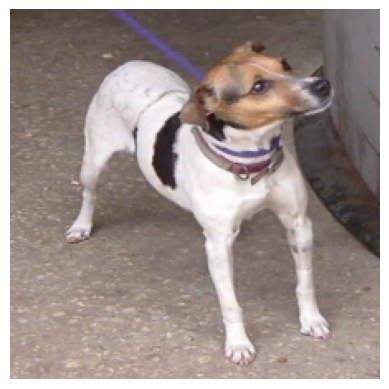

In [9]:
# Отрисуем одну картинку
imshow(image_datasets["train"].__getitem__(0)[0])

In [10]:
def train_model(model, criterion, optimizer, device, num_epochs=25):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in tqdm(dataloaders[phase]):
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.float() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path))
    return model

In [11]:
class_names = {0 : "cat", 1:"dog"}

def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[int(preds[j])]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

Далее вам нужно взять модель ResNet 18 и дообучить её на нашем датасете. Также понадобится посчитать количество параметров модели. Вы можете использовать любой код, а можете придерживаться примера ниже.

Код очень похож на первый видеоурок темы компьютерного зрения, не стесняйтесь туда подглядывать!

Ниже нужно обозначить модель, вызвать функцию обучения, и поработать с моделью.

In [22]:
model = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
model = model.to(device)


## Задание 1. Посчитайте число параметров в модели

Trainable params: 11,177,538

## Задание 2. Посчитайте Params size (MB)

Params size (MB): 44.71

In [13]:
# Возможно это вам тоже нужно
#!pip install torchinfo
# from torchinfo import summary

# summary(model, input_size=(1, 3, 224, 224))

## Задание 3. Обучите модель на 5 эпохах и запомните (или запишите) accuracy. Это понадобится для ответа на вопрос теста. Запомните и качество после первой эпохи.

Будьте готовы, что обучение займет минут 10 на ГПУ в коллабе. Это ещё быстро...

In [23]:
# YOUR CODE HERE -- TRAIN THE MODEL
model = train_model(model, criterion, optimizer, device, num_epochs=5)

# Epoch 0/4
# ----------
# 100%|██████████| 547/547 [02:03<00:00,  4.43it/s]
# train Loss: 0.1794 Acc: 0.9271
# 100%|██████████| 235/235 [00:35<00:00,  6.67it/s]
# val Loss: 0.1514 Acc: 0.9392
# ...
# Epoch 4/4
# ----------
# 100%|██████████| 547/547 [05:18<00:00,  1.72it/s]
# train Loss: 0.0707 Acc: 0.9726
# 100%|██████████| 235/235 [02:42<00:00,  1.44it/s]
# val Loss: 0.1289 Acc: 0.9536

# Training complete in 21m 51s
# Best val Acc: 0.960400

Epoch 0/4
----------


100%|██████████| 547/547 [02:03<00:00,  4.43it/s]


train Loss: 0.1794 Acc: 0.9271


100%|██████████| 235/235 [00:35<00:00,  6.67it/s]


val Loss: 0.1514 Acc: 0.9392

Epoch 1/4
----------


...

val Loss: 0.1077 Acc: 0.9593

Epoch 4/4
----------


100%|██████████| 547/547 [05:18<00:00,  1.72it/s]


train Loss: 0.0707 Acc: 0.9726


100%|██████████| 235/235 [02:42<00:00,  1.44it/s]

val Loss: 0.1289 Acc: 0.9536

Training complete in 21m 51s
Best val Acc: 0.960400


## Задание 4. Сделайте то же самое, только без предобученной архитектуры. Это задается параметром weights со значением None. Стало ли качество лучше? Запомните и его.

In [24]:
model_zero =  models.resnet18(weights=None)
num_ftrs_zero = model_zero.fc.in_features
model_zero.fc = nn.Linear(num_ftrs_zero, 2)
model_zero = model_zero.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_zero.parameters(), lr=0.001)

model_zero = model_zero.to(device)

In [25]:
# TRAIN MODEL ZERO HERE
model_zero = train_model(model_zero, criterion, optimizer, device, num_epochs=5)

# Epoch 0/4
# ----------
# 100%|██████████| 547/547 [06:36<00:00,  1.38it/s]  
# train Loss: 0.6514 Acc: 0.6254
# 100%|██████████| 235/235 [00:35<00:00,  6.71it/s]
# val Loss: 0.6224 Acc: 0.6488
# ...
# Epoch 4/4
# ----------
# 100%|██████████| 547/547 [04:10<00:00,  2.19it/s]
# train Loss: 0.3603 Acc: 0.8365
# 100%|██████████| 235/235 [00:35<00:00,  6.71it/s]
# val Loss: 0.3345 Acc: 0.8545

# Training complete in 25m 19s
# Best val Acc: 0.854533

Epoch 0/4
----------


100%|██████████| 547/547 [06:36<00:00,  1.38it/s]  


train Loss: 0.6514 Acc: 0.6254


100%|██████████| 235/235 [00:35<00:00,  6.71it/s]


val Loss: 0.6224 Acc: 0.6488

Epoch 1/4
----------


...

val Loss: 0.3977 Acc: 0.8120

Epoch 4/4
----------


100%|██████████| 547/547 [04:10<00:00,  2.19it/s]


train Loss: 0.3603 Acc: 0.8365


100%|██████████| 235/235 [00:35<00:00,  6.71it/s]


val Loss: 0.3345 Acc: 0.8545

Training complete in 25m 19s
Best val Acc: 0.854533


Посмотрим чему научилась наша модель, обученная с 0:

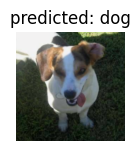

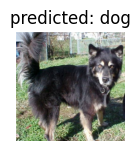

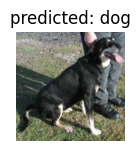

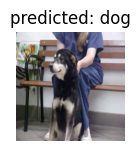

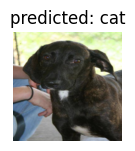

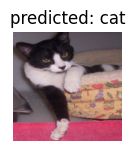

In [26]:
visualize_model(model_zero)

plt.ioff()
plt.show()

А с претрейном:

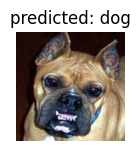

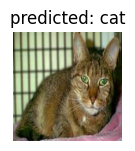

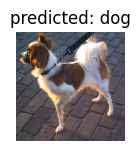

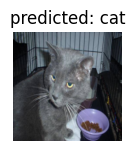

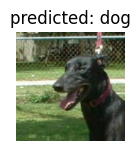

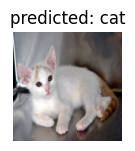

In [27]:
visualize_model(model)

plt.ioff()
plt.show()

Отлично, вы справились с задачей и изучили основы компьютерного зрения! Дальше нас ждет захватывающий мир современного CV.
